# AIMLZG546 – Software Engineering for Machine Learning
## Assignment I – Implementation Notebook (13.ipynb)

**Group No:** 13  
**Project:** Credit Card Fraud Detection

| Sl. No | BITS ID | Name | Contribution of team member (Qualitative) | Percentage Contribution (out of 100) |
|---|---|---|---|---|
| 1 | 2025ae05576 | Anirudh Anand | Report lead. Domain and problem statement, ML formulation, requirements and measurable goals (Sections 1 and 2), Business View, final report and PDF. | 25 |
| 2 | 2025ae05178 | Aniketh Paul | GR4ML Analytics Design and Data Preparation views, top three quality requirements (Sections 3.2, 3.3, 4). Data part of the pipeline: EDA, ingest, clean, features, split. | 25 |
| 3 | 2025ae05898 | Pushadapu Sanjay Kumar | Architecture diagram (ML and non-ML components), the two patterns (Sections 5 and 6). FastAPI service, input validation, prediction logging, automated tests. | 25 |
| 4 | 2025af05111 | Biswajeet Mahato | Model part of the pipeline: train and evaluate filters, threshold on validation, MLflow tracking and registry. End-to-end run, screenshots, Sections 7.2, 7.3, 8, 9. | 25 |
| | | | **Total** | **100** |

## About this notebook

This notebook implements the two architectural patterns selected in the report. The training side is a Pipe-and-Filter pipeline (ingest, clean, features, split, train, evaluate) whose best model is logged and registered in MLflow. The serving side is a separate FastAPI microservice that loads only the registered model `fraud-model@champion`, validates every request, returns a fraud probability and label, and logs every prediction.

All code files are written from the cells below using `%%writefile`, so the notebook is the single place where the code lives. Run the cells from top to bottom after a fresh runtime restart. No GPU is needed.

The dataset is the Kaggle "Credit Card Fraud Detection" file `creditcard.csv`. If the file is missing the notebook stops with an error; it never falls back to made-up data.

## 1. Setup

If a cell fails with "No such file or directory", the kernel was started in a folder that has since been deleted or renamed. Use **Restart** on the kernel and run all cells again from the top.

In [39]:
# Cell: make sure the notebook runs inside its own project folder (all code files are written here).
# If the kernel was started in a folder that no longer exists, stop with a clear message instead of failing later.
import os
from pathlib import Path

try:
    os.getcwd()
except FileNotFoundError:
    if "__vsc_ipynb_file__" not in globals():
        raise RuntimeError("The kernel's working folder no longer exists. Restart the kernel and run again.")
if "__vsc_ipynb_file__" in globals():           # VS Code: use the folder that contains 13.ipynb
    os.chdir(Path(__vsc_ipynb_file__).parent)
print("Working folder:", os.getcwd())

Working folder: /Users/sanjaykumarpushadapu/Projects/SE-ML-Assessments/Assigenment-1


In [40]:
# Cell: install the extra packages (MLflow, FastAPI, uvicorn, pydantic, httpx, pytest, requests).
%pip install -q mlflow fastapi uvicorn pydantic httpx pytest requests

Note: you may need to restart the kernel to use updated packages.


In [41]:
# Cell: create the project folders. The code files themselves are written by the %%writefile cells below.
!mkdir -p data pipeline api tests artifacts docs/screenshots
!touch pipeline/__init__.py api/__init__.py

The settings (paths, seed, targets, model name) are kept in one file so that no value is repeated in several places.

In [42]:
%%writefile config.py
"""Single place for paths, constants and targets (BR-002, BR-011).

Every other file imports its settings from here, so a value such as the seed or the
target recall is never typed in two different places.
"""
import os
from pathlib import Path

# Folder that contains this file (the project folder, i.e. where the notebook runs).
ROOT = Path(__file__).resolve().parent
SEED = 42  # fixed seed so every run gives the same split and the same model (BR-011)

# Where the data, outputs and the prediction log live.
DATA_PATH = ROOT / "data" / "creditcard.csv"
ARTIFACTS_DIR = ROOT / "artifacts"       # metrics.json and sample requests are saved here
LOG_PATH = ROOT / "predictions_log.csv"  # written by log_prediction() on every API call

# MLflow keeps its runs in a local SQLite file; model files go to the mlruns folder.
# In Docker Compose the API reaches the registry service over HTTP instead (MLFLOW_TRACKING_URI, Section 8).
TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", f"sqlite:///{ROOT / 'mlflow.db'}")
ARTIFACT_ROOT = (ROOT / "mlruns").as_uri()
EXPERIMENT = "fraud-detection"
MODEL_NAME = "fraud-model"  # name in the model registry
ALIAS = "champion"          # the API only ever loads the model that has this alias (BR-009)

# Column names of the Kaggle dataset: Time, V1..V28 (anonymised), Amount; label is Class.
V_COLS = [f"V{i}" for i in range(1, 29)]
FEATURES = ["Time"] + V_COLS + ["Amount"]
SCALED_COLS = ["Time", "Amount"]  # only these two are on very different scales, so only they are scaled
TARGET = "Class"                  # 1 = fraud, 0 = genuine

# Measurable goals from the report (Section 2.2).
TARGET_RECALL = 0.90  # catch at least 90% of the frauds
MAX_FPR = 0.02        # wrongly flag less than 2% of genuine transactions
MIN_LOSS_REDUCTION = 0.30  # business goal: cut fraud loss by 30% (measured as the share of fraud money caught)
MAX_P95_MS = 200.0    # 95% of API calls must answer within 200 ms


Overwriting config.py


### Dataset

Upload `creditcard.csv` when asked (or place it in `data/` yourself, for example from Google Drive). The cell stops with an error if the file is not there.

In [43]:
# Cell: make sure data/creditcard.csv exists. It is unzipped from data/creditcard.zip if that is there;
# otherwise Colab asks for an upload, and elsewhere the file must already be in data/.
# It stops with an error if the file is missing, so the notebook never continues with made-up data.
from pathlib import Path
import importlib.util, os

if not Path("data/creditcard.csv").exists() and Path("data/creditcard.zip").exists():
    import zipfile
    zipfile.ZipFile("data/creditcard.zip").extract("creditcard.csv", "data")

if not Path("data/creditcard.csv").exists() and importlib.util.find_spec("google.colab"):
    from google.colab import files
    uploaded = files.upload()          # choose creditcard.csv
    for name in uploaded:
        os.replace(name, "data/creditcard.csv")

assert Path("data/creditcard.csv").exists(), "Put creditcard.csv in the data/ folder next to this notebook"
print("Dataset ready:", Path("data/creditcard.csv").stat().st_size // 1_000_000, "MB")

Dataset ready: 150 MB


## 2. Exploratory data analysis

In [44]:
# Cell: first look at the raw data (shape, missing values, duplicates, class balance, Amount and Time summary).
import pandas as pd
df_raw = pd.read_csv("data/creditcard.csv")
print("Shape:", df_raw.shape)
print("Missing values:", int(df_raw.isna().sum().sum()))
print("Duplicate rows:", int(df_raw.duplicated().sum()))
counts = df_raw["Class"].value_counts()
print(counts.to_string())
print(f"Fraud rate: {100 * df_raw['Class'].mean():.3f}%")
df_raw[["Time", "Amount"]].describe().T

Shape: (284807, 31)
Missing values: 0
Duplicate rows: 1081
Class
0    284315
1       492
Fraud rate: 0.173%


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.859575,47488.145955,0.0,54201.5,84692.0,139320.500,172792.00
Amount,284807.0,88.349619,250.120109,0.0,5.6,22.0,77.165,25691.16


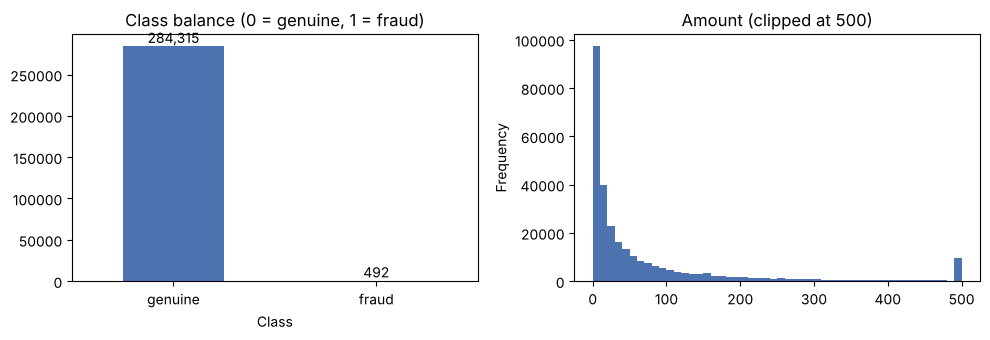

In [45]:
# Cell: plot the class balance and the Amount distribution to show how rare fraud is.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
df_raw["Class"].value_counts().plot.bar(ax=ax[0], color=["#4C72B0", "#C44E52"])
ax[0].set_title("Class balance (0 = genuine, 1 = fraud)")
ax[0].set_xticklabels(["genuine", "fraud"], rotation=0)
ax[0].bar_label(ax[0].containers[0], fmt="{:,.0f}")  # the fraud bar is too small to see, so print the counts
df_raw["Amount"].clip(upper=500).plot.hist(bins=50, ax=ax[1], color="#4C72B0")
ax[1].set_title("Amount (clipped at 500)")
plt.tight_layout(); plt.show()

### Genuine vs fraud

The next three charts compare genuine and fraud transactions on the columns the dataset has (Time, Amount and V1 to V28). The charts are only kept here in the notebook; `build_report.py` copies them, with their numbers, into 13.md and 13.pdf.

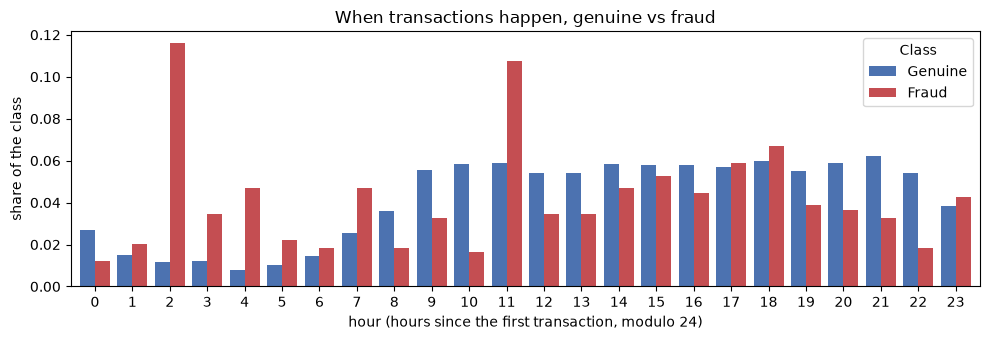

Hours 0-6: 9.8% of genuine, 27.0% of fraud transactions


In [46]:
# Cell: share of genuine and of fraud transactions in each hour (Time is seconds since the first transaction).
import pandas as pd
hour = (df_raw["Time"] // 3600 % 24).astype(int)
share = pd.crosstab(hour, df_raw["Class"], normalize="columns")  # each class adds up to 1
ax = share.rename(columns={0: "Genuine", 1: "Fraud"}).plot.bar(figsize=(10, 3.5), width=0.8,
                                                               color=["#4C72B0", "#C44E52"])
ax.set_title("When transactions happen, genuine vs fraud")
ax.set_xlabel("hour (hours since the first transaction, modulo 24)")
ax.set_ylabel("share of the class")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()
quiet = hour.isin(range(0, 7))
print(f"Hours 0-6: {100 * quiet[df_raw['Class'] == 0].mean():.1f}% of genuine, "
      f"{100 * quiet[df_raw['Class'] == 1].mean():.1f}% of fraud transactions")


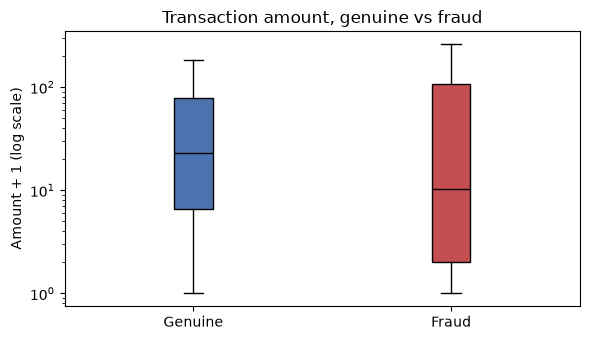

           mean    50%     95%       max
Class                                   
genuine   88.29  22.00  364.41  25691.16
fraud    122.21   9.25  640.90   2125.87


In [47]:
# Cell: Amount of genuine vs fraud transactions on a log scale (the long tail is why Amount is RobustScaled).
fig, ax = plt.subplots(figsize=(6, 3.5))
groups = [df_raw.loc[df_raw["Class"] == c, "Amount"] + 1 for c in (0, 1)]  # +1 so amounts of 0 fit a log scale
box = ax.boxplot(groups, tick_labels=["Genuine", "Fraud"], showfliers=False, patch_artist=True,
                 medianprops={"color": "black"})
for patch, colour in zip(box["boxes"], ["#4C72B0", "#C44E52"]):
    patch.set_facecolor(colour)
ax.set_yscale("log")
ax.set_ylabel("Amount + 1 (log scale)")
ax.set_title("Transaction amount, genuine vs fraud")
plt.tight_layout(); plt.show()
print(df_raw.groupby("Class")["Amount"].describe(percentiles=[0.5, 0.95])
      .rename(index={0: "genuine", 1: "fraud"})[["mean", "50%", "95%", "max"]].round(2))


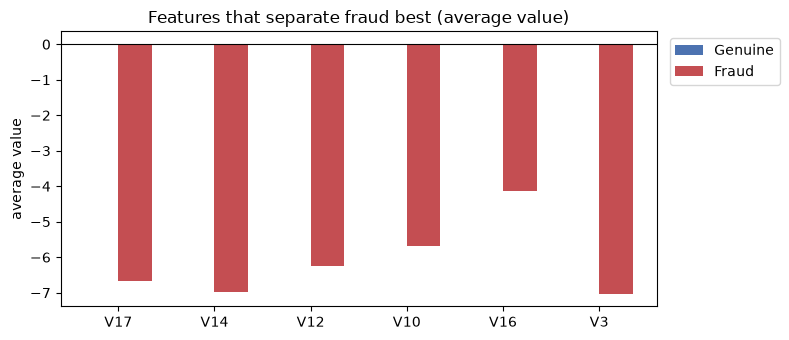

Gap in standard deviations: {'V17': 7.86, 'V14': 7.29, 'V12': 6.28, 'V10': 5.22, 'V16': 4.73, 'V3': 4.65}


In [48]:
# Cell: the V features whose average differs most between genuine and fraud (difference in standard deviations).
import config
means = df_raw.groupby("Class")[config.V_COLS].mean()
gap = ((means.loc[1] - means.loc[0]).abs() / df_raw[config.V_COLS].std()).sort_values(ascending=False)
top = list(gap.index[:6])
ax = means[top].T.rename(columns={0: "Genuine", 1: "Fraud"}).plot.bar(figsize=(8, 3.5), width=0.7,
                                                                      color=["#4C72B0", "#C44E52"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Features that separate fraud best (average value)")
ax.set_ylabel("average value")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))  # outside the plot so it hides no bar
plt.tight_layout(); plt.show()
print("Gap in standard deviations:", gap.head(6).round(2).to_dict())


## 3. Pipe-and-Filter training pipeline

Each filter is a separate function in its own module. It takes its input explicitly, returns its output, and keeps no hidden state. `run_pipeline.py` only chains them. Because the filters share the same simple interface, one of them (for example the model in `train.py`) can be swapped without touching the others.

**Filter 1 – ingest.** Reads the CSV and stops if the file or any expected column is missing.

In [49]:
%%writefile pipeline/ingest.py
"""Filter 1: read the raw CSV and check that the expected columns exist."""
from pathlib import Path

import pandas as pd

import config


def ingest(path: Path = config.DATA_PATH) -> pd.DataFrame:
    """Return the raw transactions; fail loudly if the file or columns are missing."""
    path = Path(path)
    # Stop with a clear message instead of continuing with made-up or empty data.
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found at {path}. Upload creditcard.csv first.")
    df = pd.read_csv(path)
    # A wrong or damaged file should fail here, not later inside the model.
    missing = set(config.FEATURES + [config.TARGET]) - set(df.columns)
    if missing:
        raise ValueError(f"Dataset is missing columns: {sorted(missing)}")
    return df


Overwriting pipeline/ingest.py


**Filter 2 – clean.** Removes duplicate rows and rows with missing values.

In [50]:
%%writefile pipeline/clean.py
"""Filter 2: remove duplicate rows and rows with missing values."""
import pandas as pd

import config


def clean(df: pd.DataFrame) -> pd.DataFrame:
    """Return a cleaned copy; the input frame is not modified."""
    needed = config.FEATURES + [config.TARGET]
    # drop_duplicates and dropna return new frames, so the caller's data stays unchanged.
    out = df.drop_duplicates().dropna(subset=needed).reset_index(drop=True)
    # The label must be exactly 0 or 1, otherwise the data is not what we expect.
    if not set(out[config.TARGET].unique()) <= {0, 1}:
        raise ValueError("Class column must contain only 0 and 1.")
    out[config.TARGET] = out[config.TARGET].astype(int)
    return out


Overwriting pipeline/clean.py


**Filter 3 – features.** Selects the model inputs and the label. Scaling is done later inside the model pipeline so that it is fitted on the training data only.

In [51]:
%%writefile pipeline/features.py
"""Filter 3: pick the model inputs (X) and the label (y).

Scaling is not done here. It is part of the model pipeline in train.py so that it
is fitted on the training set only (BR-003) and saved with the model (BR-004).
"""
import pandas as pd

import config


def build_features(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Return the feature table and the label column."""
    # X holds the 30 input columns as floats; y holds the fraud label.
    return df[config.FEATURES].astype(float), df[config.TARGET]


Overwriting pipeline/features.py


**Filter 4 – split.** Stratified 60/20/20 split into train, validation and test sets with a fixed seed.

In [52]:
%%writefile pipeline/split.py
"""Filter 4: stratified 60/20/20 split into train, validation and test sets."""
import pandas as pd
from sklearn.model_selection import train_test_split

import config


def split(X: pd.DataFrame, y: pd.Series, seed: int = config.SEED) -> dict:
    """Return a dict with X_/y_ for train, val and test."""
    # Step 1: keep 20% aside as the test set. stratify=y keeps the same fraud share in each part,
    # which matters because fraud is only about 0.17% of the rows.
    X_rest, X_test, y_rest, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=seed)
    # Step 2: split the remaining 80% into 60% train and 20% validation (0.25 of 80% = 20%).
    X_train, X_val, y_train, y_val = train_test_split(
        X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=seed)
    return {"X_train": X_train, "y_train": y_train, "X_val": X_val, "y_val": y_val,
            "X_test": X_test, "y_test": y_test}


Overwriting pipeline/split.py


**Filter 5 – train.** A scikit-learn Pipeline with a RobustScaler for Time and Amount and a classifier. Two candidates are available, Logistic Regression and Random Forest, both with class weights to handle the imbalance.

In [53]:
%%writefile pipeline/train.py
"""Filter 5: fit a model. The scaler and the classifier are one sklearn Pipeline."""
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

import config

CANDIDATES = ("logistic_regression", "random_forest")  # the two models we compare


def make_estimator(name: str, seed: int = config.SEED):
    """Return an unfitted classifier by name (this is the filter we can swap)."""
    if name == "logistic_regression":
        # class_weight="balanced" gives the rare fraud class a larger weight during training.
        return LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed)
    if name == "random_forest":
        # max_depth and min_samples_leaf limit the tree size so training stays fast and
        # the forest does not memorise single transactions.
        return RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=2,
                                      class_weight="balanced_subsample", n_jobs=-1,
                                      random_state=seed)
    raise ValueError(f"Unknown model name: {name}")


def train(X_train: pd.DataFrame, y_train: pd.Series, name: str) -> Pipeline:
    """Fit scaler and classifier on the training set only and return the pipeline."""
    # RobustScaler uses the median and quartiles, so a few very large Amount values
    # do not distort it. The other columns (V1..V28) are passed through unchanged.
    scale = ColumnTransformer([("scale", RobustScaler(), config.SCALED_COLS)],
                              remainder="passthrough")
    # Scaler + classifier in one object: the API loads this object, so serving applies
    # exactly the same scaling as training (BR-004).
    model = Pipeline([("prep", scale), ("clf", make_estimator(name))])
    model.fit(X_train, y_train)  # the scaler is fitted on training data only (no leakage)
    return model


Overwriting pipeline/train.py


**Filter 6 – evaluate.** The decision threshold is chosen on the validation set as the highest value that still gives recall of at least 0.90. The test set is only used once, at the end, with this threshold already fixed.

In [54]:
%%writefile pipeline/evaluate.py
"""Filter 6: choose the threshold on validation data and compute the metrics."""
import numpy as np
import pandas as pd
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score)

import config


def choose_threshold(y_true, proba, target_recall: float = config.TARGET_RECALL) -> float:
    """Highest threshold that still gives recall >= target on the given data."""
    # precision_recall_curve lists every possible threshold with its recall.
    # Recall goes down as the threshold goes up.
    _, recall, thresholds = precision_recall_curve(y_true, proba)
    # All thresholds that still reach the target recall.
    ok = np.where(recall[:-1] >= target_recall)[0]
    if len(ok) == 0:
        raise ValueError(f"Recall {target_recall} cannot be reached on this data.")
    # The last one is the highest such threshold, i.e. the fewest false alarms
    # while still meeting the recall target.
    return float(thresholds[ok[-1]])


def compute_metrics(y_true, proba, threshold: float) -> dict:
    """Recall, precision, F1, PR-AUC, ROC-AUC, FPR and the confusion matrix (BR-005)."""
    # The label is fraud when the probability reaches the threshold (BR-001).
    pred = (np.asarray(proba) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "recall": float(recall_score(y_true, pred, zero_division=0)),        # frauds caught
        "precision": float(precision_score(y_true, pred, zero_division=0)),  # flagged that are fraud
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "pr_auc": float(average_precision_score(y_true, proba)),  # threshold-free, good for rare classes
        "roc_auc": float(roc_auc_score(y_true, proba)),
        # false-positive rate = genuine transactions wrongly flagged / all genuine
        "fpr": float(fp / (fp + tn)) if (fp + tn) else 0.0,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def targets_met(metrics: dict) -> dict:
    """Compare measured values with the targets; nothing is tuned here (BR-006)."""
    flags = {"recall_ok": metrics["recall"] >= config.TARGET_RECALL,
             "fpr_ok": metrics["fpr"] < config.MAX_FPR}
    if "loss_reduction" in metrics:  # only the test report has the Amount-based loss figures
        flags["loss_ok"] = metrics["loss_reduction"] >= config.MIN_LOSS_REDUCTION
    return flags


def loss_metrics(y_true, proba, threshold: float, amount) -> dict:
    """Fraud loss measured in money (goal G4), assuming every flagged fraud is stopped.

    Loss = the Amount of the fraud transactions. Without the model every fraud goes through;
    with the model the flagged ones are blocked, so the loss reduction is the share of
    fraud money that is caught. The Amount of genuine transactions that are wrongly blocked
    is reported too, because that is the cost of the false alarms.
    """
    y = np.asarray(y_true)
    flagged = np.asarray(proba) >= threshold
    amt = np.asarray(amount, dtype=float)
    total = float(amt[y == 1].sum())
    caught = float(amt[(y == 1) & flagged].sum())
    return {"fraud_amount_total": total, "fraud_amount_caught": caught,
            "loss_reduction": caught / total if total else 0.0,
            "genuine_amount_blocked": float(amt[(y == 0) & flagged].sum())}


def evaluate_validation(model, X_val: pd.DataFrame, y_val: pd.Series) -> tuple[float, dict]:
    """Pick the threshold on the validation set and report validation metrics."""
    proba = model.predict_proba(X_val)[:, 1]  # column 1 = probability of fraud
    threshold = choose_threshold(y_val, proba)
    return threshold, compute_metrics(y_val, proba, threshold)


def evaluate_test(model, X_test: pd.DataFrame, y_test: pd.Series, threshold: float) -> dict:
    """Final report on the test set with the threshold already fixed."""
    # The threshold comes from validation; the test set is never used to choose anything.
    proba = model.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, proba, threshold)
    metrics.update(loss_metrics(y_test, proba, threshold, X_test["Amount"]))  # fraud loss in money (G4)
    return metrics


Overwriting pipeline/evaluate.py


**MLflow helper.** Logs parameters, metrics and the model for each candidate and registers the winner as `fraud-model` with the alias `champion`. This is not a filter; it only records what the pipeline produced.

In [55]:
%%writefile pipeline/registry.py
"""MLflow tracking and model registry helpers (used by run_pipeline, not a filter)."""
import mlflow
from mlflow import MlflowClient

import config


def _setup() -> None:
    """Point MLflow at the local database and create the experiment once."""
    mlflow.set_tracking_uri(config.TRACKING_URI)
    # Create the experiment with a fixed artifact folder the first time only.
    if MlflowClient().get_experiment_by_name(config.EXPERIMENT) is None:
        mlflow.create_experiment(config.EXPERIMENT, artifact_location=config.ARTIFACT_ROOT)
    mlflow.set_experiment(config.EXPERIMENT)


def log_candidate(name: str, model, X_example, threshold: float, val_metrics: dict,
                  test_metrics: dict | None = None, register: bool = False):
    """Log one candidate as an MLflow run; register it when it is the winner."""
    _setup()
    with mlflow.start_run(run_name=name) as run:
        # Parameters: what was used. The API later reads "threshold" from here (BR-002).
        mlflow.log_param("model_name", name)
        mlflow.log_param("seed", config.SEED)
        mlflow.log_param("threshold", threshold)
        # Metrics: what came out (counts such as tn/fp are left out of the metric table).
        mlflow.log_metrics({f"val_{k}": v for k, v in val_metrics.items()
                            if k not in ("tn", "fp", "fn", "tp")})
        if test_metrics is not None:  # only the winner is evaluated on the test set
            mlflow.log_metrics({f"test_{k}": v for k, v in test_metrics.items()
                                if k not in ("tn", "fp", "fn", "tp")})
        # cloudpickle is used because the default format refuses tree-based models.
        info = mlflow.sklearn.log_model(
            sk_model=model, name="model", input_example=X_example.head(2),
            serialization_format="cloudpickle",
            registered_model_name=config.MODEL_NAME if register else None)
    version = None
    if register:
        # Move the "champion" alias to the new version; the API loads whatever it points to.
        version = info.registered_model_version
        MlflowClient().set_registered_model_alias(config.MODEL_NAME, config.ALIAS, version)
    return run.info.run_id, version


Overwriting pipeline/registry.py


**Pipeline runner.** Chains the six filters, picks the candidate with the lowest validation false-positive rate (all candidates already reach recall 0.90 on validation, so the false-positive rate decides), and reports the test metrics once.

In [56]:
%%writefile pipeline/run_pipeline.py
"""Chains the filters: ingest, clean, features, split, train, evaluate (BR-010).

This file only connects the filters; the real work happens inside each filter.
"""
import json
import logging

import config
from pipeline.clean import clean
from pipeline.evaluate import evaluate_test, evaluate_validation, targets_met
from pipeline.features import build_features
from pipeline.ingest import ingest
from pipeline.split import split
from pipeline.train import CANDIDATES, train

log = logging.getLogger("pipeline")


def pick_winner(fitted: dict) -> str:
    """Candidate with the lowest validation false-positive rate; PR-AUC breaks ties.

    Every candidate already reaches the target recall on validation because its
    threshold was chosen for that, so the false-positive rate decides (goal G2).
    """
    return min(fitted, key=lambda n: (fitted[n][2]["fpr"], -fitted[n][2]["pr_auc"]))


def run_pipeline(data_path=config.DATA_PATH, candidates=CANDIDATES, track: bool = True) -> dict:
    """Run every stage, pick the candidate with the lowest validation false-positive rate, test it once."""
    # Each stage hands its output to the next one.
    raw = ingest(data_path)
    log.info("[1/6 ingest]   rows=%d columns=%d", *raw.shape)

    df = clean(raw)
    log.info("[2/6 clean]    rows=%d (removed %d), fraud=%d (%.3f%%)", len(df),
             len(raw) - len(df), df[config.TARGET].sum(), 100 * df[config.TARGET].mean())

    X, y = build_features(df)
    log.info("[3/6 features] X=%s", X.shape)

    parts = split(X, y)
    log.info("[4/6 split]    train=%d val=%d test=%d", len(parts["X_train"]),
             len(parts["X_val"]), len(parts["X_test"]))

    # Train every candidate on the training set and judge it on the validation set.
    fitted = {}
    for name in candidates:
        model = train(parts["X_train"], parts["y_train"], name)
        threshold, val_m = evaluate_validation(model, parts["X_val"], parts["y_val"])
        fitted[name] = (model, threshold, val_m)
        log.info("[5/6 train]    %-19s val recall=%.3f precision=%.3f pr_auc=%.4f threshold=%.4f",
                 name, val_m["recall"], val_m["precision"], val_m["pr_auc"], threshold)

    # The winner is chosen from validation results only. Only now is the test set used, once.
    winner = pick_winner(fitted)
    model, threshold, val_m = fitted[winner]
    test_m = evaluate_test(model, parts["X_test"], parts["y_test"], threshold)
    checks = targets_met(test_m)  # real values against the targets, nothing is adjusted
    log.info("[6/6 evaluate] winner=%s test recall=%.3f precision=%.3f f1=%.3f pr_auc=%.4f fpr=%.4f",
             winner, test_m["recall"], test_m["precision"], test_m["f1"], test_m["pr_auc"],
             test_m["fpr"])
    log.info("Targets on test set: recall>=%.2f -> %s, fpr<%.2f -> %s", config.TARGET_RECALL,
             checks["recall_ok"], config.MAX_FPR, checks["fpr_ok"])

    result = {"winner": winner, "threshold": threshold, "val": val_m, "test": test_m,
              "targets_met": checks,
              "candidates": {n: {"threshold": t, "val": m} for n, (_, t, m) in fitted.items()}}

    if track:  # track=False lets the tests run the pipeline without MLflow
        from pipeline.registry import log_candidate
        for name, (m, t, vm) in fitted.items():
            is_win = name == winner
            # Every candidate is logged for comparison; only the winner is registered.
            _, version = log_candidate(name, m, parts["X_train"], t, vm,
                                       test_m if is_win else None, register=is_win)
            if is_win:
                result["model_version"] = version
                log.info("Registered %s version %s with alias '%s'", config.MODEL_NAME,
                         version, config.ALIAS)
        # Save results and one fraud + one genuine test row for the API test calls.
        config.ARTIFACTS_DIR.mkdir(exist_ok=True)
        (config.ARTIFACTS_DIR / "metrics.json").write_text(json.dumps(result, indent=2))
        samples = {
            "fraud": parts["X_test"][parts["y_test"] == 1].iloc[0].to_dict(),
            "genuine": parts["X_test"][parts["y_test"] == 0].iloc[0].to_dict()}
        (config.ARTIFACTS_DIR / "sample_requests.json").write_text(json.dumps(samples))
    return result


if __name__ == "__main__":
    logging.basicConfig(level=logging.INFO, format="%(message)s")
    run_pipeline()


Overwriting pipeline/run_pipeline.py


### Run the pipeline

In [57]:
# Cell: run the six-filter pipeline as a separate process. It trains both models, picks the winner,
# tests it once and registers it in MLflow. Old MLflow data and the old prediction log are removed first,
# so every full run starts clean and the registry always has version 1 as the champion.
# Warnings are filtered out of the display.
!rm -rf mlruns mlflow.db predictions_log.csv
!python -m pipeline.run_pipeline 2>&1 | grep -v -i warning

[1/6 ingest]   rows=284807 columns=31
[2/6 clean]    rows=283726 (removed 1081), fraud=473 (0.167%)
[3/6 features] X=(283726, 30)
[4/6 split]    train=170235 val=56745 test=56746
[5/6 train]    logistic_regression val recall=0.904 precision=0.129 pr_auc=0.7860 threshold=0.7692
[5/6 train]    random_forest       val recall=0.904 precision=0.031 pr_auc=0.8592 threshold=0.0107
[6/6 evaluate] winner=logistic_regression test recall=0.853 precision=0.117 f1=0.206 pr_auc=0.6884 fpr=0.0108
Targets on test set: recall>=0.90 -> False, fpr<0.02 -> True
2026/10/08 07:53:06 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/08 07:53:06 INFO mlflow.store.db.utils: Updating database tables
Successfully registered model 'fraud-model'.
Created version '1' of model 'fraud-model'.
Registered fraud-model version 1 with alias 'champion'


### Results

In [58]:
# Cell: read artifacts/metrics.json and show validation results of both models next to the test result of the winner.
import json, pandas as pd
res = json.load(open("artifacts/metrics.json"))
cols = ["threshold", "recall", "precision", "f1", "pr_auc", "roc_auc", "fpr"]
table = {f"{n} (validation)": c["val"] for n, c in res["candidates"].items()}
table[f"{res['winner']} (TEST, winner)"] = res["test"]
print("Winner (lowest validation FPR):", res["winner"], "| model version:", res.get("model_version"))
display(pd.DataFrame(table).T[cols].round(4))
print("Targets on the test set:", res["targets_met"], "(recall >= 0.90, FPR < 0.02)")

Winner (lowest validation FPR): logistic_regression | model version: 1


,threshold,recall,precision,f1,pr_auc,roc_auc,fpr
logistic_regression (validation),0.7692,0.9043,0.1286,0.2252,0.7860,0.9790,0.0102
random_forest (validation),0.0107,0.9043,0.0310,0.0600,0.8592,0.9662,0.0469
"logistic_regression (TEST, winner)",0.7692,0.8526,0.1169,0.2056,0.6884,0.9644,0.0108


Targets on the test set: {'recall_ok': False, 'fpr_ok': True, 'loss_ok': True} (recall >= 0.90, FPR < 0.02)


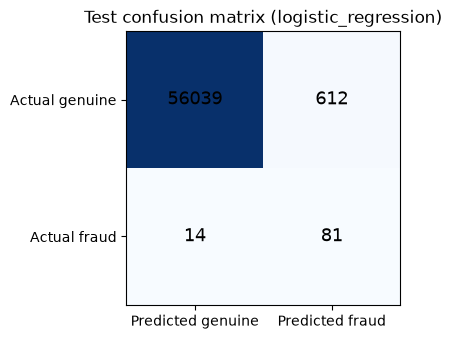

In [59]:
# Cell: draw the confusion matrix of the winner on the test set from the saved counts (tn, fp, fn, tp).
import numpy as np, matplotlib.pyplot as plt
t = res["test"]
cm = np.array([[t["tn"], t["fp"]], [t["fn"], t["tp"]]])
fig, ax = plt.subplots(figsize=(4, 3.5))
ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f"{v}", ha="center", va="center", fontsize=13)
ax.set_xticks([0, 1], ["Predicted genuine", "Predicted fraud"])
ax.set_yticks([0, 1], ["Actual genuine", "Actual fraud"])
ax.set_title(f"Test confusion matrix ({res['winner']})")
plt.tight_layout(); plt.show()

**Model comparison on the validation set.** Both models were given a threshold that reaches 90% recall on validation, so the false-positive rate decides the winner.

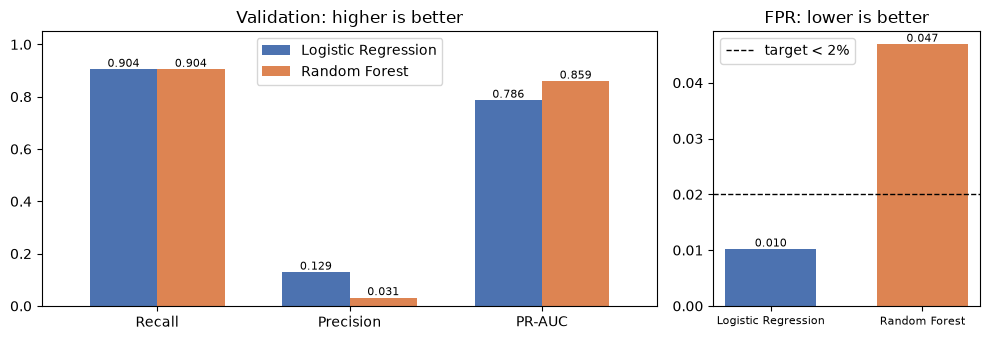

In [60]:
# Cell: compare the two candidates on the validation set (recall, precision, PR-AUC on the left, FPR on the right).
import pandas as pd, config
val = pd.DataFrame({n: c["val"] for n, c in res["candidates"].items()}).T
names = {"logistic_regression": "Logistic Regression", "random_forest": "Random Forest"}
colours = ["#4C72B0", "#DD8452"]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), gridspec_kw={"width_ratios": [3, 1.3]})
val[["recall", "precision", "pr_auc"]].T.rename(columns=names).plot.bar(ax=ax[0], width=0.7, color=colours)
ax[0].set_title("Validation: higher is better"); ax[0].set_ylim(0, 1.05)
ax[0].set_xticklabels(["Recall", "Precision", "PR-AUC"], rotation=0)
ax[1].bar([names[n] for n in val.index], val["fpr"], color=colours, width=0.6)
ax[1].axhline(config.MAX_FPR, color="black", linestyle="--", linewidth=1, label="target < 2%")
ax[1].set_title("FPR: lower is better"); ax[1].legend()
ax[1].tick_params(axis="x", labelsize=8)
for a in ax:
    for p in a.patches:
        a.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                   ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()


**Precision-recall curve on the test set.** The champion model is loaded from the registry and scores the test set again (the split uses the same seed, so it is the same test set). The red point is the threshold chosen on validation.

In [61]:
# Cell: score the test set with the registered champion model and save the scores to artifacts/test_scores.csv.
# Like the MLflow cell above, this runs in a separate process so it always reads the current MLflow database.
import subprocess, sys
score = """
import mlflow, config, pandas as pd
from pipeline.ingest import ingest
from pipeline.clean import clean
from pipeline.features import build_features
from pipeline.split import split
mlflow.set_tracking_uri(config.TRACKING_URI)
model = mlflow.sklearn.load_model(f"models:/{config.MODEL_NAME}@{config.ALIAS}")
parts = split(*build_features(clean(ingest())))
pd.DataFrame({"y": parts["y_test"].values, "prob": model.predict_proba(parts["X_test"])[:, 1]}).to_csv(
    config.ARTIFACTS_DIR / "test_scores.csv", index=False)
print("Saved", len(parts["y_test"]), "test scores")
"""
result = subprocess.run([sys.executable, "-W", "ignore", "-c", score], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr[-1500:])


Saved 56746 test scores



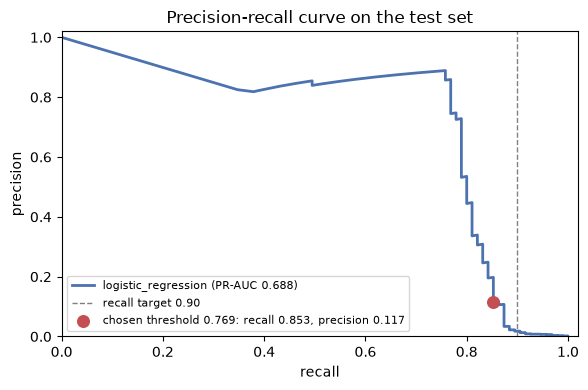

Recall 0.90 on the test set would need threshold 0.209: precision 0.018, 4690 genuine transactions flagged


In [62]:
# Cell: draw the precision-recall curve of the champion on the test set with the chosen threshold.
import numpy as np, pandas as pd, config
from sklearn.metrics import precision_recall_curve
scores = pd.read_csv("artifacts/test_scores.csv")
prec, rec, thresholds = precision_recall_curve(scores["y"], scores["prob"])
t = res["test"]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rec, prec, color="#4C72B0", linewidth=2, label=f"{res['winner']} (PR-AUC {t['pr_auc']:.3f})")
ax.axvline(config.TARGET_RECALL, color="gray", linestyle="--", linewidth=1, label="recall target 0.90")
ax.scatter([t["recall"]], [t["precision"]], s=70, color="#C44E52", zorder=3,
           label=f"chosen threshold {res['threshold']:.3f}: recall {t['recall']:.3f}, precision {t['precision']:.3f}")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
ax.set_title("Precision-recall curve on the test set")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()
# What reaching the recall target on the test set would cost (highest threshold that still reaches it).
reach = np.where(rec[:-1] >= config.TARGET_RECALL)[0][-1]
flagged = int(((scores["prob"] >= thresholds[reach]) & (scores["y"] == 0)).sum())
print(f"Recall {config.TARGET_RECALL:.2f} on the test set would need threshold {thresholds[reach]:.3g}: "
      f"precision {prec[reach]:.3f}, {flagged} genuine transactions flagged")


## 4. MLflow tracking and model registry

Every candidate is logged as a run with its parameters and metrics. The winner is registered as `fraud-model` and given the alias `champion`. The serving microservice loads only this alias.

In [63]:
# Cell: show the MLflow runs (parameters and metrics) and the registered model with its champion alias.
# This is done in a separate Python process so it always reads the current MLflow database
# (a kernel that stays open can keep an old, deleted database in memory after a re-run).
import subprocess, sys
query = """
import mlflow, config
from mlflow import MlflowClient
mlflow.set_tracking_uri(config.TRACKING_URI)
runs = mlflow.search_runs(experiment_names=[config.EXPERIMENT])
keep = ["tags.mlflow.runName", "params.threshold", "metrics.val_recall", "metrics.val_precision",
        "metrics.val_pr_auc", "metrics.test_recall", "metrics.test_precision", "metrics.test_pr_auc"]
print(runs[[c for c in keep if c in runs.columns]].round(4).to_string())
client = MlflowClient()
for mv in client.search_model_versions(f"name='{config.MODEL_NAME}'"):
    print(f"Registered model: {mv.name}  version: {mv.version}  run: {mv.run_id}")
champ = client.get_model_version_by_alias(config.MODEL_NAME, config.ALIAS)
print(f"Alias '{config.ALIAS}' points to version {champ.version}")
"""
result = subprocess.run([sys.executable, "-W", "ignore", "-c", query], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr[-1500:])

   tags.mlflow.runName      params.threshold  metrics.val_recall  metrics.val_precision  metrics.val_pr_auc  metrics.test_recall  metrics.test_precision  metrics.test_pr_auc
0        random_forest  0.010731109047411747              0.9043                 0.0310              0.8592                  NaN                     NaN                  NaN
1  logistic_regression    0.7691996767092619              0.9043                 0.1286              0.7860               0.8526                  0.1169               0.6884
Registered model: fraud-model  version: 1  run: 87fc7b51bf6b4cbba4d33951bc747cd3
Alias 'champion' points to version 1



## 5. Prediction microservice (FastAPI)

The service is a separate process. At start-up it loads `models:/fraud-model@champion` and the threshold stored with that model. Requests are validated with pydantic: a missing field, a wrong type, NaN or infinity, a negative Amount or an unknown field is rejected with HTTP 422. The response contains the probability, the label (`probability >= threshold`) and the model version. Each successful call is written to the prediction log.

In [64]:
%%writefile api/prediction_log.py
"""Non-ML component: append one row per prediction to a CSV file (BR-008)."""
import csv
import threading
from datetime import datetime, timezone
from pathlib import Path

import config

FIELDS = ["timestamp", "request_id", "probability", "is_fraud", "latency_ms", "model_version"]
_lock = threading.Lock()  # two requests at the same time must not write into the file together


def log_prediction(request_id: str, probability: float, is_fraud: bool, latency_ms: float,
                   model_version: str, path: Path | None = None) -> None:
    """Write one log row; an OSError is raised if the file cannot be written."""
    path = Path(path or config.LOG_PATH)
    # Only result data is logged. The transaction values themselves are not stored.
    row = {"timestamp": datetime.now(timezone.utc).isoformat(), "request_id": request_id,
           "probability": round(probability, 6), "is_fraud": int(is_fraud),
           "latency_ms": round(latency_ms, 3), "model_version": model_version}
    with _lock:
        new_file = not path.exists() or path.stat().st_size == 0  # write the header once
        with path.open("a", newline="") as f:  # "a" = append, old rows are kept
            writer = csv.DictWriter(f, fieldnames=FIELDS)
            if new_file:
                writer.writeheader()
            writer.writerow(row)


Overwriting api/prediction_log.py


In [65]:
%%writefile api/main.py
"""Prediction microservice. It only loads the registered champion model; it never trains."""
import logging
import time
import uuid
from contextlib import asynccontextmanager

import mlflow
import mlflow.sklearn
import pandas as pd
from fastapi import FastAPI, HTTPException, Request
from fastapi.exceptions import RequestValidationError
from fastapi.responses import JSONResponse
from mlflow import MlflowClient
from pydantic import BaseModel, ConfigDict, Field, create_model

import config
from api.prediction_log import log_prediction

log = logging.getLogger("api")

# Request schema: one required float for each of the 30 model inputs.
# allow_inf_nan=False rejects NaN and infinity; Amount must also be zero or more.
_fields = {c: (float, Field(..., allow_inf_nan=False)) for c in config.FEATURES}
_fields["Amount"] = (float, Field(..., ge=0, allow_inf_nan=False))
# extra="forbid" rejects unknown fields (for example a card number) with HTTP 422.
Transaction = create_model("Transaction", __config__=ConfigDict(extra="forbid"), **_fields)


class Prediction(BaseModel):
    """What the service sends back for one transaction."""
    request_id: str
    probability: float
    is_fraud: bool
    threshold: float
    model_version: str
    latency_ms: float


def load_champion():
    """Load models:/fraud-model@champion, its version and its threshold (BR-002, BR-009)."""
    mlflow.set_tracking_uri(config.TRACKING_URI)
    # Only the registered model with the champion alias is served, never a file or a run.
    model = mlflow.sklearn.load_model(f"models:/{config.MODEL_NAME}@{config.ALIAS}")
    client = MlflowClient()
    mv = client.get_model_version_by_alias(config.MODEL_NAME, config.ALIAS)
    # The threshold was chosen during evaluation and stored as a run parameter,
    # so the service reads it instead of having its own copy.
    threshold = float(client.get_run(mv.run_id).data.params["threshold"])
    return model, str(mv.version), threshold


@asynccontextmanager
async def lifespan(app: FastAPI):
    """Runs once when the service starts: load the model into memory (keeps latency low)."""
    app.state.model, app.state.version, app.state.threshold = load_champion()
    log.info("Loaded %s version %s, threshold %.4f", config.MODEL_NAME, app.state.version,
             app.state.threshold)
    yield


app = FastAPI(title="Credit Card Fraud Detection Service", lifespan=lifespan)


@app.exception_handler(RequestValidationError)
async def validation_error_handler(request: Request, exc: RequestValidationError):
    """Return 422 without echoing the input (a NaN value cannot be serialised back)."""
    errors = [{"loc": list(e["loc"]), "msg": e["msg"], "type": e["type"]} for e in exc.errors()]
    return JSONResponse(status_code=422, content={"detail": errors})


@app.get("/health")
def health() -> dict:
    """Report that the service is up and which model version it serves."""
    return {"status": "ok", "model": config.MODEL_NAME, "model_version": app.state.version,
            "threshold": app.state.threshold}


@app.post("/predict", response_model=Prediction)
def predict(tx: Transaction) -> Prediction:
    """Score one transaction; the label is probability >= threshold and nothing else (BR-001)."""
    start = time.perf_counter()
    # Invalid requests never reach this point, FastAPI has already answered with 422.
    row = pd.DataFrame([tx.model_dump()], columns=config.FEATURES)
    # The saved model scales the input itself, so no separate preprocessing is done here (BR-004).
    probability = float(app.state.model.predict_proba(row)[0, 1])
    is_fraud = probability >= app.state.threshold
    latency_ms = (time.perf_counter() - start) * 1000
    request_id = str(uuid.uuid4())  # unique id so a log row can be matched to a call
    try:
        log_prediction(request_id, probability, is_fraud, latency_ms, app.state.version)
    except OSError as exc:
        # A failed log write is reported as an error, never ignored (BR-008).
        raise HTTPException(status_code=500, detail=f"Prediction log failed: {exc}") from exc
    return Prediction(request_id=request_id, probability=probability, is_fraud=is_fraud,
                      threshold=app.state.threshold, model_version=app.state.version,
                      latency_ms=round(latency_ms, 3))


Overwriting api/main.py


### Start the service in the background

In [66]:
# Cell: start the FastAPI service in the background and wait until /health answers (stops with an error after 90 s).
import subprocess, time, requests
api = subprocess.Popen(["uvicorn", "api.main:app", "--port", "8000"],
                       stdout=open("api.log", "w"), stderr=subprocess.STDOUT)
for _ in range(90):
    try:
        health = requests.get("http://localhost:8000/health", timeout=2).json()
        break
    except requests.exceptions.ConnectionError:
        time.sleep(1)
else:
    raise RuntimeError("API did not start, see api.log:\n" + open("api.log").read())
print(health)

{'status': 'ok', 'model': 'fraud-model', 'model_version': '1', 'threshold': 0.7691996767092619}


The endpoints of the service, read from its OpenAPI description:

In [67]:
# Cell: list the endpoints of the running service from its OpenAPI description.
spec = requests.get("http://localhost:8000/openapi.json").json()
for path, methods in spec["paths"].items():
    print(path, list(methods))

/health ['get']
/predict ['post']


The interactive `/docs` page used for the screenshot (works inside Colab):

In [68]:
# Cell: show the interactive /docs page inside Colab; outside Colab it prints the address to open in a browser.
import importlib.util
if importlib.util.find_spec("google.colab"):
    from google.colab import output
    output.serve_kernel_port_as_iframe(8000, path="/docs", height=700)
else:
    print("Not running in Colab. Open http://localhost:8000/docs in your browser for the screenshot.")

Not running in Colab. Open http://localhost:8000/docs in your browser for the screenshot.


## 6. Test calls

One fraud row and one genuine row, both taken from the test set (they were saved by the pipeline).

In [69]:
# Cell: send one fraud row and one genuine row (saved by the pipeline from the test set) to /predict.
import json
samples = json.load(open("artifacts/sample_requests.json"))
for kind, payload in samples.items():
    r = requests.post("http://localhost:8000/predict", json=payload)
    print(f"--- {kind} transaction (HTTP {r.status_code})")
    print(json.dumps(r.json(), indent=2))

--- fraud transaction (HTTP 200)
{
  "request_id": "4a220cdd-5cb0-4691-85aa-3061869d4d59",
  "probability": 0.9999999998115439,
  "is_fraud": true,
  "threshold": 0.7691996767092619,
  "model_version": "1",
  "latency_ms": 15.433
}
--- genuine transaction (HTTP 200)
{
  "request_id": "8f567137-7e55-4824-98dc-7020ade22e83",
  "probability": 0.027732497926819904,
  "is_fraud": false,
  "threshold": 0.7691996767092619,
  "model_version": "1",
  "latency_ms": 2.305
}


Invalid inputs must be rejected and must not be logged (a negative amount, a missing field, an unknown field).

In [70]:
# Cell: send three invalid requests; each must be answered with HTTP 422 and must not be logged.
bad_amount = dict(samples["genuine"], Amount=-5.0)
missing = {k: v for k, v in samples["genuine"].items() if k != "V5"}
extra = dict(samples["genuine"], card_number="4111111111111111")
for label, payload in [("negative Amount", bad_amount), ("missing V5", missing), ("unknown field", extra)]:
    r = requests.post("http://localhost:8000/predict", json=payload)
    print(f"{label:16s} -> HTTP {r.status_code}", r.json()["detail"][0]["msg"])

negative Amount  -> HTTP 422 Input should be greater than or equal to 0
missing V5       -> HTTP 422 Field required
unknown field    -> HTTP 422 Extra inputs are not permitted


### Latency (target: p95 below 200 ms)

In [71]:
# Cell: send 100 requests and measure the response time to check the target p95 < 200 ms.
import config
import numpy as np, time
lat = []
for _ in range(100):
    t0 = time.perf_counter()
    requests.post("http://localhost:8000/predict", json=samples["genuine"])
    lat.append((time.perf_counter() - t0) * 1000)
p95 = float(np.percentile(lat, 95))
print(f"100 requests: median {np.median(lat):.1f} ms, p95 {p95:.1f} ms, max {max(lat):.1f} ms")
print("p95 target met:", p95 < config.MAX_P95_MS)

100 requests: median 4.2 ms, p95 5.2 ms, max 7.1 ms
p95 target met: True


### Prediction log

In [72]:
# Cell: show the prediction log; it should contain one row per successful call (the calls above).
import config
log = pd.read_csv(config.LOG_PATH)
print("Rows logged:", len(log))
log.tail(5)

Rows logged: 102


,timestamp,request_id,probability,is_fraud,latency_ms,model_version
97,2026-10-08T02:23:26.787106+00:00,c051f8f4-3163-4a69-9f3d-2e81c5207771,0.027732,0,2.155,1
98,2026-10-08T02:23:26.790890+00:00,caf5cccc-e021-411c-8757-eeb22d83a634,0.027732,0,1.649,1
99,2026-10-08T02:23:26.794552+00:00,540c282f-22da-48fe-8155-5a410fca44d6,0.027732,0,1.831,1
100,2026-10-08T02:23:26.798930+00:00,97cb8af6-1161-48e4-9100-1f467868aa3f,0.027732,0,1.911,1
101,2026-10-08T02:23:26.803021+00:00,910bcfc2-c3d9-4ae7-83c1-8ea36ab80a3f,0.027732,0,2.150,1


## 7. Automated tests

The tests are named after the rules they check (for example `test_BR007_...` checks input validation). They use a small synthetic table created inside the tests, so they do not need the Kaggle file or a running server.

In [73]:
%%writefile tests/conftest.py
"""Shared fixtures. The tiny dataset here is synthetic and used for unit tests only."""
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import pytest

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))

import config  # noqa: E402


@pytest.fixture(scope="session")
def tiny_df() -> pd.DataFrame:
    """Small synthetic table (1000 rows, 50 frauds) used only by the tests, not the Kaggle data."""
    rng = np.random.default_rng(config.SEED)
    n, n_fraud = 1000, 50
    y = np.array([0] * (n - n_fraud) + [1] * n_fraud)
    X = rng.normal(0, 1, size=(n, 28)) + y[:, None] * 1.5
    df = pd.DataFrame(X, columns=config.V_COLS)
    df.insert(0, "Time", np.sort(rng.uniform(0, 172800, n)))
    df["Amount"] = rng.exponential(60, n)
    df["Class"] = y
    return df.sample(frac=1, random_state=config.SEED).reset_index(drop=True)


@pytest.fixture(scope="session")
def tiny_parts(tiny_df):
    """Train/validation/test parts of the tiny table, made with the real split filter."""
    from pipeline.features import build_features
    from pipeline.split import split
    X, y = build_features(tiny_df)
    return split(X, y)


@pytest.fixture(scope="session")
def tiny_model(tiny_parts):
    """A logistic regression pipeline fitted on the tiny training part with the real train filter."""
    from pipeline.train import train
    return train(tiny_parts["X_train"], tiny_parts["y_train"], "logistic_regression")


@pytest.fixture()
def valid_payload(tiny_df) -> dict:
    """One valid API request body taken from the tiny table."""
    row = tiny_df[config.FEATURES].iloc[0]
    return {k: float(v) for k, v in row.items()}

Overwriting tests/conftest.py


In [74]:
%%writefile tests/test_pipeline.py
"""Tests for the pipeline filters and the rules BR-002 to BR-006, BR-010 and BR-011."""
import inspect
import json

import joblib
import numpy as np
import pandas as pd
import pytest

import config
from pipeline import clean as clean_mod, evaluate, features, ingest as ingest_mod, split as split_mod
from pipeline import train as train_mod
from pipeline import run_pipeline as rp


# ---- BR-002 threshold chosen on validation ---------------------------------------------
def test_BR002_threshold_meets_target_recall_on_validation(tiny_model, tiny_parts):
    """The chosen threshold must reach the target recall on the validation set."""
    thr, val_m = evaluate.evaluate_validation(tiny_model, tiny_parts["X_val"], tiny_parts["y_val"])
    assert val_m["recall"] >= config.TARGET_RECALL
    assert val_m["threshold"] == thr


def test_BR002_unreachable_recall_raises():
    """If the target recall cannot be reached, choose_threshold must raise an error and not guess."""
    with pytest.raises(ValueError):
        evaluate.choose_threshold([0, 1, 1], [0.9, 0.1, 0.2], target_recall=1.01)


def test_BR002_threshold_not_hard_coded_in_api():
    """The API must read the threshold from MLflow and must not contain its own fixed value."""
    import api.main as api_main
    src = inspect.getsource(api_main)
    assert "params[\"threshold\"]" in src and ">= 0." not in src


# ---- BR-003 no leakage -----------------------------------------------------------------
def test_BR003_splits_are_disjoint_and_stratified(tiny_parts):
    """Train, validation and test must not share rows and must have the same fraud share."""
    idx = [set(tiny_parts[f"X_{k}"].index) for k in ("train", "val", "test")]
    assert not (idx[0] & idx[1]) and not (idx[0] & idx[2]) and not (idx[1] & idx[2])
    rates = [tiny_parts[f"y_{k}"].mean() for k in ("train", "val", "test")]
    assert max(rates) - min(rates) < 0.01
    assert sum(len(i) for i in idx) == 1000


def test_BR003_scaler_fitted_on_train_only(tiny_model, tiny_parts, tiny_df):
    """The scaler must use the training median of Amount, not the median of all data (no leakage)."""
    scaler = tiny_model.named_steps["prep"].named_transformers_["scale"]
    train_median = tiny_parts["X_train"]["Amount"].median()
    all_median = tiny_df["Amount"].median()
    assert scaler.center_[1] == pytest.approx(train_median)
    assert train_median != pytest.approx(all_median)


# ---- BR-004 same preprocessing in training and serving ---------------------------------
def test_BR004_preprocessing_saved_inside_model(tiny_model, tiny_parts, tmp_path):
    """The scaler is saved inside the model, and a saved and reloaded model gives identical results."""
    assert "prep" in tiny_model.named_steps
    path = tmp_path / "m.pkl"
    joblib.dump(tiny_model, path)
    reloaded = joblib.load(path)
    X = tiny_parts["X_test"]
    np.testing.assert_allclose(reloaded.predict_proba(X), tiny_model.predict_proba(X))


# ---- BR-005 / BR-006 metrics and honest targets ----------------------------------------
def test_BR005_metrics_include_required_measures():
    """Metrics must include recall, precision, F1, PR-AUC and the confusion matrix, and not accuracy."""
    m = evaluate.compute_metrics([0, 0, 1, 1], [0.1, 0.6, 0.4, 0.9], 0.5)
    for key in ("recall", "precision", "f1", "pr_auc", "tn", "fp", "fn", "tp"):
        assert key in m
    assert "accuracy" not in m
    assert (m["tn"], m["fp"], m["fn"], m["tp"]) == (1, 1, 1, 1)


def test_BR006_targets_flag_is_false_when_target_missed():
    """When the targets are missed, the result must say so (False) instead of hiding it."""
    bad = evaluate.compute_metrics([0, 0, 1, 1], [0.1, 0.6, 0.4, 0.9], 0.5)
    flags = evaluate.targets_met(bad)
    assert flags["recall_ok"] is False and flags["fpr_ok"] is False


def test_BR006_test_set_not_used_for_threshold():
    """The threshold is chosen on validation data first; the test set is used only afterwards."""
    src = inspect.getsource(rp.run_pipeline)
    assert src.index("evaluate_validation") < src.index("evaluate_test")
    assert "choose_threshold" not in src


# ---- BR-010 pipe-and-filter ------------------------------------------------------------
def test_BR010_filters_do_not_mutate_their_input(tiny_df):
    """Filters must return new data and leave the input table unchanged."""
    before = tiny_df.copy(deep=True)
    clean_mod.clean(tiny_df)
    features.build_features(tiny_df)
    pd.testing.assert_frame_equal(tiny_df, before)


def test_BR010_each_filter_is_a_separate_function():
    """Each filter is its own function in its own module."""
    for fn in (ingest_mod.ingest, clean_mod.clean, features.build_features, split_mod.split,
               train_mod.train, evaluate.evaluate_validation, evaluate.evaluate_test):
        assert callable(fn)
    assert len({f.__module__ for f in (ingest_mod.ingest, clean_mod.clean, split_mod.split)}) == 3


def test_BR010_run_pipeline_chains_filters_in_order(monkeypatch, tiny_df, tmp_path):
    """run_pipeline must call the filters in the order ingest, clean, features, split, train, evaluate."""
    calls = []

    def spy(name, fn):
        def wrapper(*a, **k):
            calls.append(name)
            return fn(*a, **k)
        return wrapper

    for name in ("ingest", "clean", "build_features", "split", "train", "evaluate_validation",
                 "evaluate_test"):
        monkeypatch.setattr(rp, name, spy(name, getattr(rp, name)))
    path = tmp_path / "creditcard.csv"
    tiny_df.to_csv(path, index=False)
    rp.run_pipeline(path, candidates=("logistic_regression",), track=False)
    order = ["ingest", "clean", "build_features", "split", "train", "evaluate_validation",
             "evaluate_test"]
    assert calls == order


def test_BR010_ingest_fails_loudly(tmp_path):
    """ingest must raise an error for a missing file and for a file with wrong columns."""
    with pytest.raises(FileNotFoundError):
        ingest_mod.ingest(tmp_path / "missing.csv")
    bad = tmp_path / "bad.csv"
    pd.DataFrame({"a": [1]}).to_csv(bad, index=False)
    with pytest.raises(ValueError):
        ingest_mod.ingest(bad)


# ---- BR-011 seeds ----------------------------------------------------------------------
def test_BR011_seed_is_42_everywhere():
    """The configured seed and the models' random_state must be 42."""
    assert config.SEED == 42
    for name in train_mod.CANDIDATES:
        assert train_mod.make_estimator(name).random_state == 42


def test_BR011_same_seed_gives_same_split_and_results(tiny_df, tmp_path):
    """Running the pipeline twice must give exactly the same test results."""
    path = tmp_path / "c.csv"
    tiny_df.to_csv(path, index=False)
    a = rp.run_pipeline(path, candidates=("logistic_regression",), track=False)
    b = rp.run_pipeline(path, candidates=("logistic_regression",), track=False)
    assert json.dumps(a["test"], sort_keys=True) == json.dumps(b["test"], sort_keys=True)


def test_BR006_winner_is_lowest_validation_fpr_then_pr_auc():
    """The winner has the lowest validation false-positive rate; PR-AUC only breaks ties."""
    fitted = {"a": (None, 0.5, {"fpr": 0.04, "pr_auc": 0.9}),
              "b": (None, 0.5, {"fpr": 0.01, "pr_auc": 0.8}),
              "c": (None, 0.5, {"fpr": 0.01, "pr_auc": 0.7})}
    assert rp.pick_winner(fitted) == "b"


def test_BR006_fraud_loss_reduction_is_share_of_fraud_money_caught():
    """Loss reduction = Amount of caught frauds / Amount of all frauds; genuine blocked money is reported too."""
    m = evaluate.loss_metrics([1, 1, 0, 0], [0.9, 0.1, 0.8, 0.2], 0.5, [100.0, 300.0, 50.0, 70.0])
    assert m["fraud_amount_total"] == 400.0 and m["fraud_amount_caught"] == 100.0
    assert m["loss_reduction"] == 0.25 and m["genuine_amount_blocked"] == 50.0


Overwriting tests/test_pipeline.py


In [75]:
%%writefile tests/test_api.py
"""Tests for the prediction API: BR-001, BR-007, BR-008 and BR-009."""
import csv

import pytest
from fastapi.testclient import TestClient

import api.main as api_main
import config


@pytest.fixture()
def client(monkeypatch, tiny_model, tmp_path):
    """Test client for the API with a small model, threshold 0.5, model version 7 and a temporary log file."""
    monkeypatch.setattr(api_main, "load_champion", lambda: (tiny_model, "7", 0.5))
    monkeypatch.setattr(config, "LOG_PATH", tmp_path / "log.csv")
    with TestClient(api_main.app) as c:
        yield c


# ---- BR-001 ----------------------------------------------------------------------------
def test_BR001_label_is_probability_against_threshold(client, valid_payload):
    """The label must equal (probability >= threshold) and the probability must be between 0 and 1."""
    r = client.post("/predict", json=valid_payload)
    assert r.status_code == 200
    body = r.json()
    assert 0.0 <= body["probability"] <= 1.0
    assert body["is_fraud"] == (body["probability"] >= body["threshold"])


def test_BR001_boundary_probability_equal_to_threshold_is_fraud(monkeypatch, tiny_model,
                                                                tmp_path, valid_payload):
    """A probability exactly equal to the threshold counts as fraud (boundary case)."""
    p = float(tiny_model.predict_proba(
        __import__("pandas").DataFrame([valid_payload], columns=config.FEATURES))[0, 1])
    monkeypatch.setattr(api_main, "load_champion", lambda: (tiny_model, "7", p))
    monkeypatch.setattr(config, "LOG_PATH", tmp_path / "log.csv")
    with TestClient(api_main.app) as c:
        assert c.post("/predict", json=valid_payload).json()["is_fraud"] is True


# ---- BR-007 ----------------------------------------------------------------------------
def test_BR007_missing_field_rejected(client, valid_payload):
    """A request with a missing feature must get HTTP 422."""
    del valid_payload["V5"]
    assert client.post("/predict", json=valid_payload).status_code == 422


def test_BR007_negative_amount_rejected(client, valid_payload):
    """A negative Amount must get HTTP 422."""
    valid_payload["Amount"] = -1.0
    assert client.post("/predict", json=valid_payload).status_code == 422


def test_BR007_wrong_type_rejected(client, valid_payload):
    """A text value where a number is expected must get HTTP 422."""
    valid_payload["V1"] = "abc"
    assert client.post("/predict", json=valid_payload).status_code == 422


def test_BR007_extra_field_rejected(client, valid_payload):
    """An unknown field (for example a card number) must get HTTP 422."""
    valid_payload["card_number"] = "4111111111111111"
    assert client.post("/predict", json=valid_payload).status_code == 422


@pytest.mark.parametrize("bad", ["NaN", "Infinity", "-Infinity"])
def test_BR007_nan_and_inf_rejected(client, valid_payload, bad):
    """NaN and infinity must get HTTP 422 and must not be logged."""
    parts = [f'"{k}": {bad if k == "V2" else v}' for k, v in valid_payload.items()]
    r = client.post("/predict", content="{" + ", ".join(parts) + "}",
                    headers={"content-type": "application/json"})
    assert r.status_code == 422
    assert not config.LOG_PATH.exists()


def test_BR007_invalid_input_is_not_logged(client, valid_payload):
    """A rejected request must not create a log row."""
    valid_payload["Amount"] = -5.0
    client.post("/predict", json=valid_payload)
    assert not config.LOG_PATH.exists()


# ---- BR-008 ----------------------------------------------------------------------------
def test_BR008_every_call_is_logged(client, valid_payload):
    """Each successful call writes one log row with the expected columns and no feature values."""
    for _ in range(3):
        assert client.post("/predict", json=valid_payload).status_code == 200
    rows = list(csv.DictReader(config.LOG_PATH.open()))
    assert len(rows) == 3
    assert set(rows[0]) == {"timestamp", "request_id", "probability", "is_fraud",
                            "latency_ms", "model_version"}
    assert rows[0]["model_version"] == "7"
    assert not any(k.startswith("V") for k in rows[0])


def test_BR008_log_failure_is_an_error_not_silent(monkeypatch, tiny_model, tmp_path, valid_payload):
    """If the log cannot be written the API must answer HTTP 500, not continue silently."""
    monkeypatch.setattr(api_main, "load_champion", lambda: (tiny_model, "7", 0.5))
    monkeypatch.setattr(config, "LOG_PATH", tmp_path)  # a directory cannot be opened as a file
    with TestClient(api_main.app) as c:
        r = c.post("/predict", json=valid_payload)
    assert r.status_code == 500 and "log failed" in r.json()["detail"]


# ---- BR-009 ----------------------------------------------------------------------------
def test_BR009_loads_only_the_champion_alias(monkeypatch):
    """The API must load models:/fraud-model@champion and take the threshold from that model's run."""
    seen = {}

    class FakeMV:
        version = 3
        run_id = "abc"

    class FakeRun:
        class data:
            params = {"threshold": "0.25"}

    class FakeClient:
        def get_model_version_by_alias(self, name, alias):
            seen["alias"] = (name, alias)
            return FakeMV()

        def get_run(self, run_id):
            return FakeRun()

    monkeypatch.setattr("mlflow.sklearn.load_model",
                        lambda uri: seen.setdefault("uri", uri) or "model")
    monkeypatch.setattr(api_main, "MlflowClient", FakeClient)
    _, version, threshold = api_main.load_champion()
    assert seen["uri"] == "models:/fraud-model@champion"
    assert seen["alias"] == ("fraud-model", "champion")
    assert (version, threshold) == ("3", 0.25)


def test_BR009_response_carries_model_version(client, valid_payload):
    """Responses and /health must show the model version being served."""
    assert client.post("/predict", json=valid_payload).json()["model_version"] == "7"
    assert client.get("/health").json()["model_version"] == "7"


def test_BR009_tracking_uri_can_point_to_registry_service(monkeypatch):
    """In Docker Compose the API must reach the registry service through MLFLOW_TRACKING_URI."""
    import importlib
    monkeypatch.setenv("MLFLOW_TRACKING_URI", "http://registry:5000")
    assert importlib.reload(config).TRACKING_URI == "http://registry:5000"
    monkeypatch.delenv("MLFLOW_TRACKING_URI")
    assert importlib.reload(config).TRACKING_URI.startswith("sqlite:///")  # default: the local file


Overwriting tests/test_api.py


In [76]:
# Cell: run all automated tests. The test names show which business rule (BR-xxx) each one checks.
!python -m pytest -q -p no:warnings tests/ 2>&1 | tail -15

................................                                         [100%]
32 passed in 2.24s


### Stop the service

In [77]:
# Cell: stop the background API process.
api.terminate(); api.wait(); print('API stopped')

API stopped


## 8. Containerised deployment (two microservices)

The same code also runs as two separate services with Docker Compose:

- **registry**: the MLflow tracking server with the model registry (port 5000).
- **prediction-api**: the FastAPI service (port 8000). It finds the champion model through the registry service over HTTP (`MLFLOW_TRACKING_URI=http://registry:5000`) instead of opening the database file itself.

Both services use one image built from the `Dockerfile`. The registry keeps the model files inside this project folder, so both containers mount the folder at the same path as on the host. The cells below write the three files. The last cell builds and starts both services, calls the API through them and stops them again. It is skipped when Docker is not installed (for example in Colab).

To start the services by hand: `docker compose up -d --build`, then open http://localhost:8000/docs and http://localhost:5000.

In [ ]:
%%writefile requirements-api.txt
# Packages for the two containers. Pinned to the versions the registered model was saved with.
mlflow==3.17.0
scikit-learn==1.9.1
numpy==2.5.3
pandas==3.0.6
scipy==1.18.1
cloudpickle==3.1.2
psutil==7.2.2
fastapi
uvicorn
pydantic>=2


In [ ]:
%%writefile Dockerfile
# One image for both services (registry and prediction-api); docker-compose.yml chooses the command.
# Python 3.14 is the version the registered model was saved with.
FROM python:3.14-slim
WORKDIR /app
COPY requirements-api.txt .
RUN pip install --no-cache-dir -r requirements-api.txt
# The project folder (code, mlflow.db and mlruns) is mounted at run time, see docker-compose.yml.
ENV MLFLOW_DISABLE_AGENT_HINT=1 PYTHONUNBUFFERED=1


In [ ]:
%%writefile .dockerignore
# Only the requirements file is copied into the image; everything else is mounted at run time,
# so the large dataset is not sent to Docker during the build.
*
!requirements-api.txt


In [ ]:
%%writefile docker-compose.yml
# Two microservices: the model registry and the prediction API.
# ${PWD} is this project folder. It is mounted at the same path inside both containers because
# the registry stores the model files with their full path in this folder.
services:
  registry:
    build: .
    image: fraud-detection:1.0
    working_dir: ${PWD}
    volumes:
      - ${PWD}:${PWD}
    command: >
      mlflow server --backend-store-uri sqlite:///${PWD}/mlflow.db
      --default-artifact-root ${PWD}/mlruns --host 0.0.0.0 --port 5000 --allowed-hosts "*"
    ports:
      - "5000:5000"
    healthcheck:
      test: ["CMD", "python", "-c", "import urllib.request; urllib.request.urlopen('http://localhost:5000/health')"]
      interval: 5s
      retries: 24

  prediction-api:
    image: fraud-detection:1.0
    working_dir: ${PWD}
    volumes:
      - ${PWD}:${PWD}
    environment:
      MLFLOW_TRACKING_URI: http://registry:5000   # the API asks the registry service for the champion model
    command: uvicorn api.main:app --host 0.0.0.0 --port 8000
    ports:
      - "8000:8000"
    depends_on:
      registry:
        condition: service_healthy   # start only when the registry answers
    healthcheck:
      test: ["CMD", "python", "-c", "import urllib.request; urllib.request.urlopen('http://localhost:8000/health')"]
      interval: 5s
      retries: 24


In [ ]:
# Cell: build and start both containers, call the API through them, then stop them (skipped when Docker is missing).
import os, shutil, subprocess, json, requests
if shutil.which("docker") is None:
    print("Docker is not installed here, so this step is skipped.")
else:
    env = {**os.environ, "PWD": os.getcwd()}  # docker-compose.yml mounts this folder
    compose = lambda *a: subprocess.run(["docker", "compose", *a], capture_output=True, text=True, env=env)
    up = compose("up", "-d", "--build", "--wait")
    if up.returncode != 0:
        print(up.stderr[-2000:])
    else:
        print(compose("ps", "--format", "table {{.Service}}\t{{.Image}}\t{{.Status}}\t{{.Ports}}").stdout)
        print("GET  http://localhost:8000/health ->", requests.get("http://localhost:8000/health").json())
        r = requests.post("http://localhost:8000/predict", json=samples["fraud"]).json()
        print("POST http://localhost:8000/predict (fraud row) ->",
              json.dumps({k: r[k] for k in ("probability", "is_fraud", "threshold", "model_version")}))
        reg = requests.get("http://localhost:5000/api/2.0/mlflow/registered-models/alias",
                           params={"name": "fraud-model", "alias": "champion"}).json()
        print("GET  http://localhost:5000 registry: fraud-model@champion -> version",
              reg["model_version"]["version"])
    compose("down")
    print("containers stopped")


SERVICE          IMAGE                 STATUS                    PORTS
prediction-api   fraud-detection:1.0   Up 5 seconds (healthy)    0.0.0.0:8000->8000/tcp
registry         fraud-detection:1.0   Up 17 seconds (healthy)   0.0.0.0:5000->5000/tcp

GET  http://localhost:8000/health -> {'status': 'ok', 'model': 'fraud-model', 'model_version': '1', 'threshold': 0.7691996767092619}
POST http://localhost:8000/predict (fraud row) -> {"probability": 0.9999999998115439, "is_fraud": true, "threshold": 0.7691996767092619, "model_version": "1"}
GET  http://localhost:5000 registry: fraud-model@champion -> version 1
containers stopped
